In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Outliers

An outlier is a data point that differs significantly from other observations in a dataset. It may be unusually high or low compared to the rest of the data.

An outlier is dangerous when it significantly distorts analysis or model performance, leading to misleading conclusions or incorrect predictions.

# How To Treat Outliers

1. Trimming
2. Capping

### Trimming

Trimming is the process of removing extreme values (outliers) from a dataset. Typically, values below a certain lower percentile (like the 1st percentile) or above a higher percentile (like the 99th percentile) are deleted entirely from the data.

Purpose: To eliminate the influence of extreme values that could skew analysis.

Use case: When outliers are errors or irrelevant to your analysis.

Downside: You lose data, which can be risky in small datasets.

###  Capping (Winsorizing)

Capping, also known as Winsorizing, involves replacing extreme outlier values with threshold values (like the 5th and 95th percentiles), rather than removing them.

Purpose: To reduce the effect of outliers without deleting data.

Use case: When you want to preserve dataset size but limit outlier influence.

Downside: Can still mask extreme values and may not be suitable for certain analyses.

📌 Example: Replace values above the 95th percentile with the value at the 95th percentile.

# How To Detect Outliers?

1. Using the IQR (Interquartile Range) Method
2. Z-Score Method
3. Boxplot (Visual Method)


# Outlier Detection and Removal Using Z-Score Method

In [3]:
df = pd.read_csv('is_placed.csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


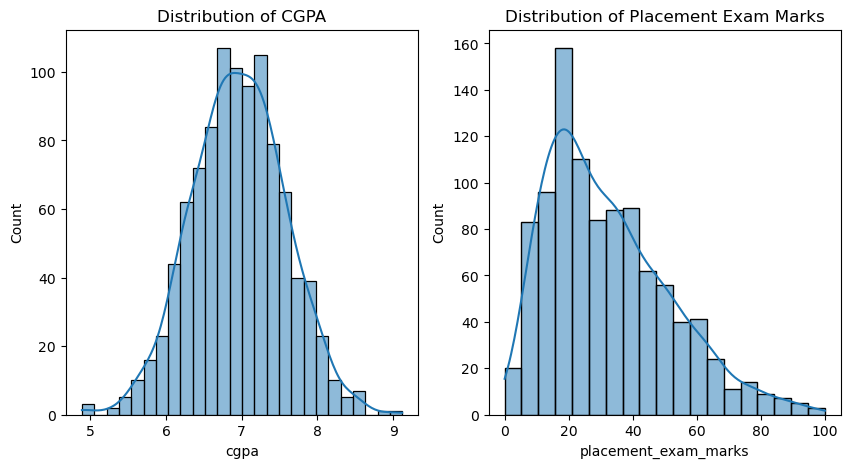

In [5]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title("Distribution of CGPA")

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title("Distribution of Placement Exam Marks")


plt.show()

In [6]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [9]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Minimum value of cgpa",df['cgpa'].max())
print("Maximum value of cgpa",df['cgpa'].min())
print("standar deviation of cgpa",df['cgpa'].std())

Mean value of cgpa 6.96124
Minimum value of cgpa 9.12
Maximum value of cgpa 4.89
standar deviation of cgpa 0.6158978751323894


In [11]:
print("Highest allowed value ",df['cgpa'].mean() + 3 * df['cgpa'].std())
print("Lowest allowed value ",df['cgpa'].mean() - 3 * df['cgpa'].std())

Highest allowed value  8.808933625397168
Lowest allowed value  5.113546374602832


In [14]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [21]:
# finding the outliers
df[(df['cgpa'] > 8.80 )| (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


#### Trimming

In [22]:
# trimming

new_df = df[(df['cgpa'] < 8.80 ) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [24]:
# calculating the Z score
# z = value - mean / standard deviation

In [25]:
df['cgpa_zcore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [26]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zcore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [27]:
df[df['cgpa_zcore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zcore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [29]:
df[df['cgpa_zcore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zcore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [33]:
df[(df['cgpa_zcore'] > 3) | (df['cgpa_zcore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zcore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [34]:
# Trimming

In [35]:
new_df = df[(df['cgpa_zcore'] < 3) & (df['cgpa_zcore'] > -3)]

In [36]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zcore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [37]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

In [38]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [39]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zcore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [40]:
df.shape

(1000, 4)

In [41]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

# Outlier Detection and Removal using the IQR Method

In [48]:
df.sample(5)

,cgpa,placement_exam_marks,placed
950,6.65,33.0,1
314,7.43,14.0,1
357,7.92,42.0,1
822,7.33,32.0,1
129,6.81,39.0,1


In [49]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

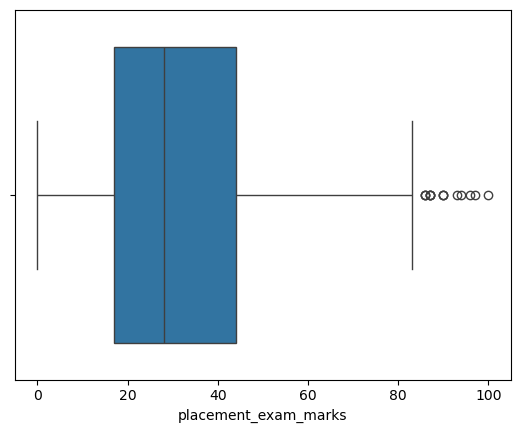

In [53]:

sns.boxplot(df['placement_exam_marks'],orient='h')

In [55]:
percentile_25 = df['placement_exam_marks'].quantile(0.25)
percentile_75 = df['placement_exam_marks'].quantile(0.75)


In [56]:
percentile_25

17.0

In [57]:
iqr = percentile_75 - percentile_25
iqr

27.0

In [58]:
upper_limit = percentile_75 + 1.5 * iqr
lower_limit = percentile_25 - 1.5 * iqr

In [59]:
print("Upper Limit",upper_limit)
print("Lower Limit",lower_limit)

Upper Limit 84.5
Lower Limit -23.5


In [60]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


#### Trimming

In [61]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [62]:
new_df.shape

(985, 3)

#### capping

In [63]:
new_df_cap = df.copy()

In [66]:
new_df_cap = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(new_df_cap['placement_exam_marks'] < lower_limit,
             lower_limit,
             new_df_cap['placement_exam_marks'])
)

# Outlier Detection using the Percentile Method

In [69]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='cgpa'>

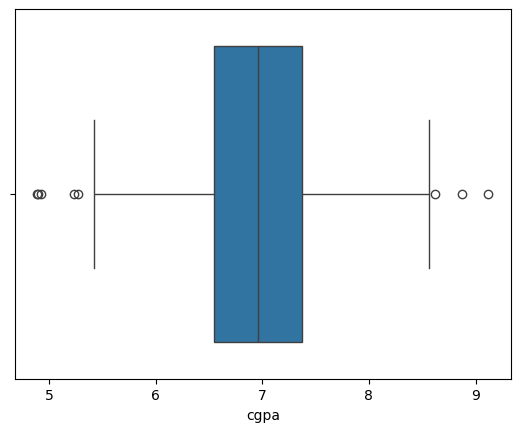

In [72]:
sns.boxplot(df['cgpa'],orient='h')

In [73]:
upper_limit = df['cgpa'].quantile(0.99)
upper_limit

8.4201

In [74]:
lower_limit = df['cgpa'].quantile(0.01)
lower_limit

5.5596

In [78]:
new_dff = df[(df['cgpa'] <= upper_limit) & (df['cgpa'] >= lower_limit)]

In [80]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [79]:
new_dff['cgpa'].describe()

count    980.000000
mean       6.961745
std        0.573327
min        5.560000
25%        6.557500
50%        6.960000
75%        7.360000
max        8.420000
Name: cgpa, dtype: float64

<Axes: xlabel='cgpa'>

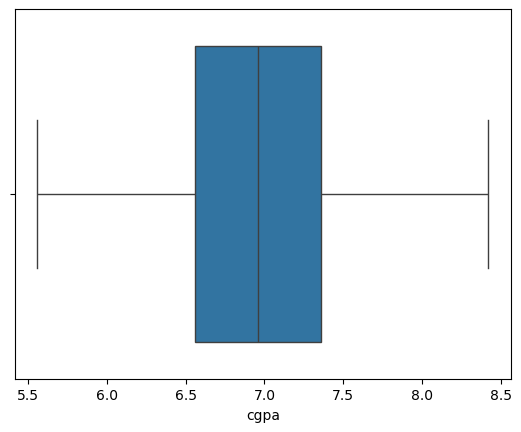

In [82]:
sns.boxplot(new_dff['cgpa'],orient='h')

In [83]:
# capping

####  Winsorization

In [85]:
newdf = df.copy()

In [ ]:
np.where()

In [87]:
newdf['cgpa'] = np.where(df['cgpa'] >= upper_limit,
         upper_limit,
         np.where(df['cgpa'] <= lower_limit,
                  lower_limit,
                  df['cgpa'])
        )

In [88]:
newdf['cgpa'].describe()

count    1000.000000
mean        6.962307
std         0.602571
min         5.559600
25%         6.550000
50%         6.960000
75%         7.370000
max         8.420100
Name: cgpa, dtype: float64

In [90]:
from scipy.stats.mstats import winsorize
winsorized_data = winsorize(df['cgpa'], limits=(0.05, 0.05))

print("Original:", df['cgpa'])
print("Winsorized:", list(winsorized_data))

Original: 0      7.19
1      7.46
2      7.54
3      6.42
4      7.23
       ... 
995    8.87
996    9.12
997    4.89
998    8.62
999    4.90
Name: cgpa, Length: 1000, dtype: float64
Winsorized: [7.19, 7.46, 7.54, 6.42, 7.23, 7.3, 6.69, 7.12, 6.45, 7.75, 6.82, 6.38, 6.58, 5.97, 7.91, 7.1, 6.53, 7.56, 6.93, 7.63, 6.69, 7.43, 6.76, 6.05, 6.44, 6.28, 7.45, 6.53, 7.23, 6.51, 7.46, 7.66, 5.97, 6.23, 7.95, 7.48, 6.85, 7.95, 6.58, 7.25, 6.6, 6.7, 7.46, 7.85, 7.88, 6.92, 7.3, 6.92, 6.29, 7.95, 6.2, 6.24, 7.53, 6.69, 7.95, 7.95, 6.93, 7.73, 7.34, 7.7, 7.94, 7.51, 7.61, 6.22, 6.98, 6.27, 6.67, 7.95, 6.58, 7.41, 6.98, 6.13, 7.9, 6.39, 6.16, 6.77, 7.95, 7.1, 7.95, 7.63, 6.87, 7.12, 7.22, 7.38, 5.97, 6.03, 7.19, 6.96, 6.78, 6.56, 7.61, 7.42, 6.48, 7.0, 7.15, 6.89, 7.09, 7.33, 7.95, 7.46, 6.56, 6.48, 5.97, 6.44, 6.82, 6.72, 6.59, 7.32, 5.97, 7.23, 6.96, 6.48, 7.23, 7.24, 6.3, 7.28, 7.16, 7.11, 6.9, 7.0, 6.99, 5.97, 5.97, 6.25, 6.2, 7.46, 7.16, 6.95, 6.76, 6.81, 5.97, 7.95, 7.71, 7.65, 6.33, 6.63, 7.